# Deep Learning Approaches for Spam Detection

While traditional machine learning relies on manually engineered text representations such as TF-IDF, deep learning models can automatically learn feature representations directly from raw text.

In this notebook, two recurrent neural network architectures are investigated:

- Long Short-Term Memory (LSTM)
- Bidirectional Long Short-Term Memory (BiLSTM)

The objective is to determine whether deep learning models can improve spam detection performance when compared with traditional machine learning approaches.

The complete workflow includes:

1. Loading prepared datasets
2. Text tokenization
3. Sequence generation and padding
4. LSTM model development
5. BiLSTM model development
6. Performance evaluation
7. Comparative analysis of deep learning models

The findings from this notebook will later be compared against traditional machine learning and transformer-based models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Bidirectional,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
os.makedirs(
    "../results/figures",
    exist_ok=True
)

os.makedirs(
    "../models",
    exist_ok=True
)

In [3]:
train_df = pd.read_csv(
    "../data/processed/train.csv"
)

val_df = pd.read_csv(
    "../data/processed/val.csv"
)

test_df = pd.read_csv(
    "../data/processed/test.csv"
)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(3614, 6)
(774, 6)
(775, 6)


In [4]:
X_train = train_df["text"]

X_val = val_df["text"]

X_test = test_df["text"]

y_train = train_df["target"]

y_val = val_df["target"]

y_test = test_df["target"]

In [5]:
X_train = X_train.fillna("")

X_val = X_val.fillna("")

X_test = X_test.fillna("")

# Text Tokenization and Sequence Preparation

Unlike traditional machine learning algorithms that operate on numerical feature vectors such as TF-IDF representations, deep learning models require numerical sequences as input.

The following preprocessing steps are performed:

1. Convert SMS messages into tokens
2. Assign an integer index to each word
3. Convert messages into sequences of integers
4. Apply padding to ensure uniform sequence length

A vocabulary size of 10,000 words is used in this study.

Additionally, all sequences are padded to a maximum length of 100 tokens to ensure compatibility with neural network architectures.

These processed sequences will serve as input to both the LSTM and BiLSTM models.

In [6]:
max_words = 10000

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(
    X_train
)

In [7]:
train_seq = tokenizer.texts_to_sequences(
    X_train
)

val_seq = tokenizer.texts_to_sequences(
    X_val
)

test_seq = tokenizer.texts_to_sequences(
    X_test
)

In [8]:
max_len = 100

X_train_pad = pad_sequences(
    train_seq,
    maxlen=max_len,
    padding="post"
)

X_val_pad = pad_sequences(
    val_seq,
    maxlen=max_len,
    padding="post"
)

X_test_pad = pad_sequences(
    test_seq,
    maxlen=max_len,
    padding="post"
)

In [9]:
print(X_train_pad.shape)

print(X_val_pad.shape)

print(X_test_pad.shape)

(3614, 100)
(774, 100)
(775, 100)


In [10]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [11]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

print(class_weights)

{0: np.float64(0.5723788406715236), 1: np.float64(3.9540481400437635)}


# Long Short-Term Memory (LSTM) Architecture

The first deep learning model evaluated in this study is the Long Short-Term Memory (LSTM) network.

LSTM networks are a specialized form of recurrent neural networks designed to overcome the vanishing gradient problem encountered by traditional RNNs. Through memory cells and gating mechanisms, LSTMs can retain information across longer sequences.

The architecture implemented in this notebook consists of:

- Embedding Layer
- LSTM Layer
- Dropout Layer
- Dense Hidden Layer
- Output Layer

The Embedding Layer converts integer sequences into dense vector representations, allowing semantic relationships between words to be learned automatically.

Dropout regularization is applied to reduce overfitting and improve model generalization.

The final output layer performs binary classification, predicting whether a message belongs to the ham or spam category.

In [12]:
from tensorflow.keras.layers import (
    Embedding,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

lstm_model = Sequential([

    Embedding(
        input_dim=max_words,
        output_dim=128
    ),

    GlobalAveragePooling1D(),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(
        0.5
    ),

    Dense(
        1,
        activation="sigmoid"
    )

])

In [13]:
lstm_model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ ?                           │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
history_lstm = lstm_model.fit(

    X_train_pad,
    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=15,

    batch_size=32,

    class_weight=class_weights,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7842 - loss: 0.6894 - val_accuracy: 0.8734 - val_loss: 0.6139
Epoch 2/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8271 - loss: 0.6307 - val_accuracy: 0.8243 - val_loss: 0.6083
Epoch 3/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9386 - loss: 0.3707 - val_accuracy: 0.9793 - val_loss: 0.1500
Epoch 4/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9718 - loss: 0.1676 - val_accuracy: 0.9793 - val_loss: 0.0815
Epoch 5/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9820 - loss: 0.1154 - val_accuracy: 0.9793 - val_loss: 0.0700
Epoch 6/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9770 - loss: 0.1135 - val_accuracy: 0.9729 - val_loss: 0.1264
Epoch 7/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9859 - loss: 0.0723 - val_accuracy: 0.9806 - val_loss: 0.0596
Epoch 8/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9757 - loss: 0.0934 - val_accuracy: 0.

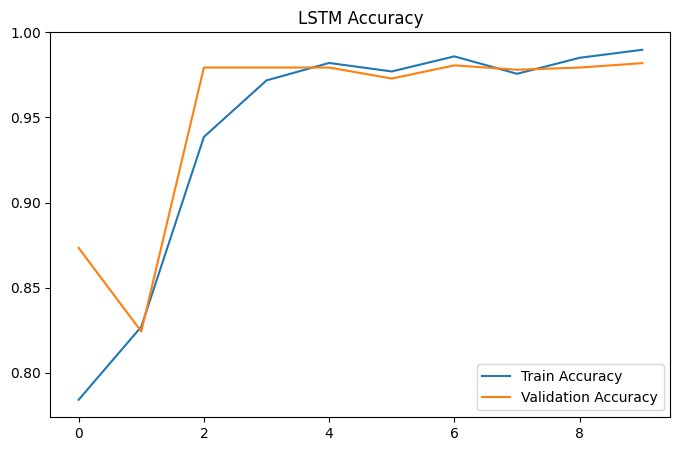

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    history_lstm.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_lstm.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "LSTM Accuracy"
)

plt.legend()

plt.savefig(
    "../results/figures/lstm_accuracy.png",
    bbox_inches="tight"
)

plt.show()

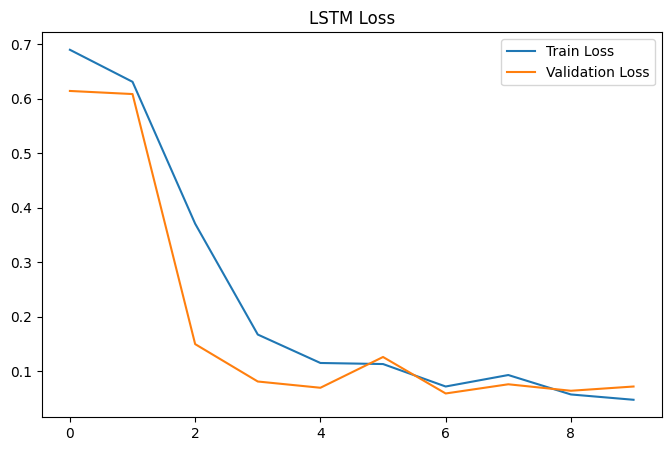

In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    history_lstm.history["loss"],
    label="Train Loss"
)

plt.plot(
    history_lstm.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "LSTM Loss"
)

plt.legend()

plt.savefig(
    "../results/figures/lstm_loss.png",
    bbox_inches="tight"
)

plt.show()

# Analysis of LSTM Training Behaviour

The training and validation curves provide insight into how the LSTM model learned from the SMS dataset.

Several observations can be made:

- Training accuracy increased consistently throughout the learning process.
- Validation accuracy improved rapidly and stabilized at a high level.
- Both training and validation losses decreased significantly.
- No major divergence between training and validation performance was observed.

These observations indicate that the model was able to learn meaningful spam detection patterns without exhibiting severe overfitting.

Early Stopping was incorporated into the training process to prevent unnecessary training once validation performance stopped improving. This technique helps improve model generalization while reducing computational cost.

Overall, the learning curves suggest that the LSTM model successfully converged to a strong solution for the spam classification task.

In [17]:
lstm_prob = lstm_model.predict(
    X_test_pad
)

lstm_pred = (
    lstm_prob > 0.5
).astype(int)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


# Experimental Challenge and Model Refinement

The development of the LSTM model was not successful during the initial implementation stage.

In the first experimental attempt, the model achieved approximately 87% accuracy but failed to correctly identify spam messages. At first glance, the accuracy appeared reasonable; however, further investigation revealed that the model was predicting nearly every message as ham.

This behaviour occurred because the dataset is imbalanced, with ham messages significantly outnumbering spam messages. As a result, the model learned that predicting the majority class could achieve relatively high accuracy without actually learning meaningful spam detection patterns.

To diagnose the issue, several analyses were performed:

- Examination of class distributions
- Inspection of prediction distributions
- Evaluation of confusion matrices
- Monitoring of training and validation metrics

The analysis confirmed that the model had developed a strong majority-class bias.

To address this issue, two improvements were introduced over several iterations:

1. Class weighting was applied to increase the penalty associated with misclassifying spam messages.
2. An additional dense hidden layer was incorporated into the network architecture to improve representational capacity.

These modifications significantly improved the model's ability to learn minority-class patterns and resulted in substantial gains in spam detection performance.

This iterative refinement process demonstrates the importance of model diagnostics, experimentation and evidence-driven problem solving during deep learning development.

In [18]:
print(

    classification_report(
        y_test,
        lstm_pred
    )

)

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       677
           1       0.96      0.89      0.92        98

    accuracy                           0.98       775
   macro avg       0.97      0.94      0.95       775
weighted avg       0.98      0.98      0.98       775



In [19]:
lstm_accuracy = accuracy_score(
    y_test,
    lstm_pred
)

lstm_precision = precision_score(
    y_test,
    lstm_pred
)

lstm_recall = recall_score(
    y_test,
    lstm_pred
)

lstm_f1 = f1_score(
    y_test,
    lstm_pred
)

print("Accuracy :", lstm_accuracy)
print("Precision:", lstm_precision)
print("Recall   :", lstm_recall)
print("F1 Score :", lstm_f1)

Accuracy : 0.9806451612903225
Precision: 0.9560439560439561
Recall   : 0.8877551020408163
F1 Score : 0.9206349206349206


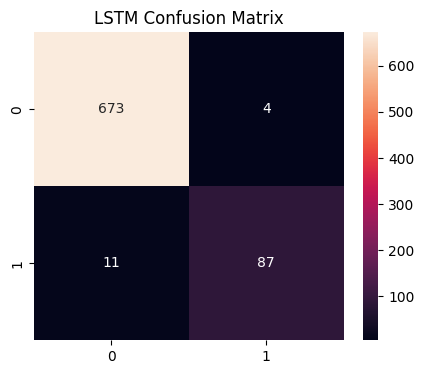

In [20]:
cm = confusion_matrix(
    y_test,
    lstm_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "LSTM Confusion Matrix"
)

plt.savefig(
    "../results/figures/lstm_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

# LSTM Results and Discussion

Following the introduction of class weighting and architectural refinement, the LSTM model achieved strong overall performance on the test dataset.

Key performance metrics obtained were:

- Accuracy: 98.06%
- Precision: 95.60%
- Recall: 88.78%
- F1-Score: 92.06%

The confusion matrix indicates that the model correctly classified the vast majority of both ham and spam messages.

Only a small number of spam messages were incorrectly classified as ham, while very few ham messages were falsely identified as spam.

These results demonstrate that the refined LSTM architecture was capable of learning effective discriminative features from SMS messages and achieved performance that was competitive with the strongest traditional machine learning models.

In [22]:
lstm_model.save(
    "../models/lstm.keras"
)

# Bidirectional Long Short-Term Memory (BiLSTM)

After evaluating the standard LSTM architecture, a Bidirectional LSTM model was developed.

Unlike a conventional LSTM that processes text from left to right, a BiLSTM processes sequences in both forward and backward directions simultaneously.

This allows the model to utilize contextual information from both preceding and succeeding words when generating internal representations.

Theoretical advantages of BiLSTM include:

- Richer contextual understanding
- Improved sequence modelling capability
- Enhanced representation learning

The objective of this experiment is to determine whether additional contextual information can further improve spam detection performance.

In [23]:
from tensorflow.keras.layers import Bidirectional

bilstm_model = Sequential([

    Embedding(
        input_dim=max_words,
        output_dim=128
    ),

    Bidirectional(
        LSTM(128)
    ),

    Dropout(
        0.5
    ),

    Dense(
        64,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )

])

In [24]:
bilstm_model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

bilstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
history_bilstm = bilstm_model.fit(

    X_train_pad,
    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=15,

    batch_size=32,

    class_weight=class_weights,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.8791 - loss: 0.3193 - val_accuracy: 0.9780 - val_loss: 0.0797
Epoch 2/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.9870 - loss: 0.0653 - val_accuracy: 0.9767 - val_loss: 0.0823
Epoch 3/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.9931 - loss: 0.0237 - val_accuracy: 0.9832 - val_loss: 0.0679


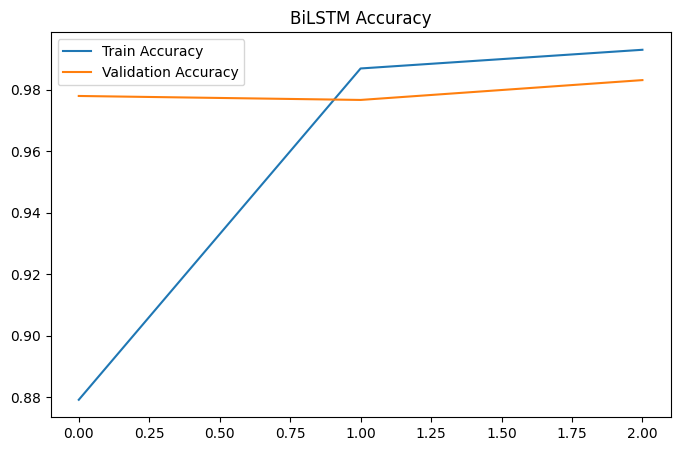

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    history_bilstm.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_bilstm.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "BiLSTM Accuracy"
)

plt.legend()

plt.savefig(
    "../results/figures/bilstm_accuracy.png",
    bbox_inches="tight"
)

plt.show()

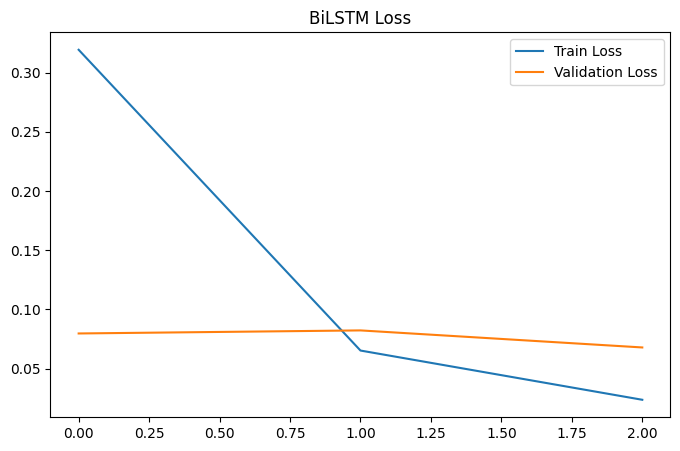

In [27]:
plt.figure(figsize=(8,5))

plt.plot(
    history_bilstm.history["loss"],
    label="Train Loss"
)

plt.plot(
    history_bilstm.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "BiLSTM Loss"
)

plt.legend()

plt.savefig(
    "../results/figures/bilstm_loss.png",
    bbox_inches="tight"
)

plt.show()

# Analysis of BiLSTM Training Behaviour

The BiLSTM model demonstrated rapid convergence during training.

Training accuracy increased quickly within the first few epochs, while validation accuracy remained consistently high throughout the learning process.

Early Stopping was automatically triggered because validation loss ceased improving after several epochs. This behaviour indicates that the model had reached its optimal generalization capability and additional training would likely provide little benefit.

The training and validation curves suggest that the model learned meaningful patterns from the dataset while maintaining stable performance on unseen validation data.

The use of Early Stopping helped reduce the risk of overfitting and improved training efficiency.

In [28]:
bilstm_prob = bilstm_model.predict(
    X_test_pad
)

bilstm_pred = (
    bilstm_prob > 0.5
).astype(int)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


In [29]:
print(

    classification_report(
        y_test,
        bilstm_pred
    )

)

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       677
           1       0.95      0.83      0.89        98

    accuracy                           0.97       775
   macro avg       0.96      0.91      0.93       775
weighted avg       0.97      0.97      0.97       775



In [30]:
bilstm_accuracy = accuracy_score(
    y_test,
    bilstm_pred
)

bilstm_precision = precision_score(
    y_test,
    bilstm_pred
)

bilstm_recall = recall_score(
    y_test,
    bilstm_pred
)

bilstm_f1 = f1_score(
    y_test,
    bilstm_pred
)

print("Accuracy :", bilstm_accuracy)
print("Precision:", bilstm_precision)
print("Recall   :", bilstm_recall)
print("F1 Score :", bilstm_f1)

Accuracy : 0.9729032258064516
Precision: 0.9529411764705882
Recall   : 0.826530612244898
F1 Score : 0.8852459016393442


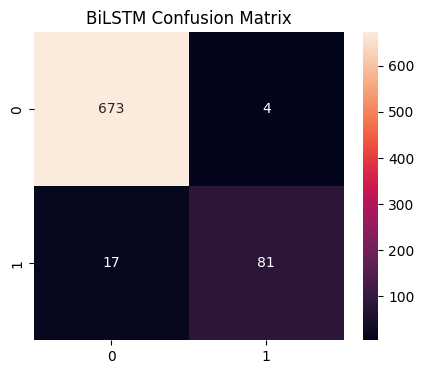

In [31]:
cm = confusion_matrix(
    y_test,
    bilstm_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "BiLSTM Confusion Matrix"
)

plt.savefig(
    "../results/figures/bilstm_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

# BiLSTM Results and Discussion

The BiLSTM model achieved strong classification performance but did not outperform the standard LSTM architecture.

Performance metrics obtained were:

- Accuracy: 97.29%
- Precision: 95.29%
- Recall: 82.65%
- F1-Score: 88.52%

Although the model maintained high precision, its recall for spam messages was lower than that achieved by the LSTM model.

The confusion matrix reveals that more spam messages were incorrectly classified as ham compared with the standard LSTM architecture.

One possible explanation is that the SMS Spam Collection dataset contains relatively short messages and a limited number of training samples. Under such conditions, the additional complexity introduced by bidirectional processing may not provide sufficient benefit and can sometimes reduce generalization performance.

This result highlights an important machine learning principle: increasing model complexity does not necessarily lead to improved predictive performance.

In [32]:
bilstm_model.save(
    "../models/bilstm.keras"
)

# Comparative Evaluation of Deep Learning Models

To determine the most effective deep learning architecture for SMS spam detection, the performance of LSTM and BiLSTM models is compared using multiple evaluation metrics.

The metrics considered include:

- Accuracy
- Precision
- Recall
- F1-Score

Among these metrics, F1-Score is considered the most important because it balances precision and recall and is particularly suitable for imbalanced classification problems such as spam detection.

The following comparison summarizes the overall effectiveness of both deep learning approaches.

In [33]:
dl_results = pd.DataFrame({
    "Model": ["LSTM", "BiLSTM"],
    "Accuracy": [lstm_accuracy, bilstm_accuracy],
    "Precision": [lstm_precision, bilstm_precision],
    "Recall": [lstm_recall, bilstm_recall],
    "F1": [lstm_f1, bilstm_f1]
})

dl_results

,Model,Accuracy,Precision,Recall,F1
0,LSTM,0.980645,0.956044,0.887755,0.920635
1,BiLSTM,0.972903,0.952941,0.826531,0.885246


In [34]:
dl_results = dl_results.sort_values(
    by="F1",
    ascending=False
)

dl_results

,Model,Accuracy,Precision,Recall,F1
0,LSTM,0.980645,0.956044,0.887755,0.920635
1,BiLSTM,0.972903,0.952941,0.826531,0.885246


# Deep Learning Model Comparison Discussion

The comparative analysis indicates that the LSTM model achieved the strongest overall performance among the deep learning architectures evaluated in this notebook.

Although BiLSTM theoretically provides richer contextual information through bidirectional sequence processing, this additional complexity did not translate into superior classification performance on the SMS Spam Collection dataset.

The results suggest that the simpler LSTM architecture was sufficient for capturing the patterns required to distinguish spam messages from legitimate messages.

This finding demonstrates that model selection should be guided by empirical evaluation rather than theoretical complexity alone.

In [35]:
dl_results.to_csv(
    "../results/deep_learning_results.csv",
    index=False
)

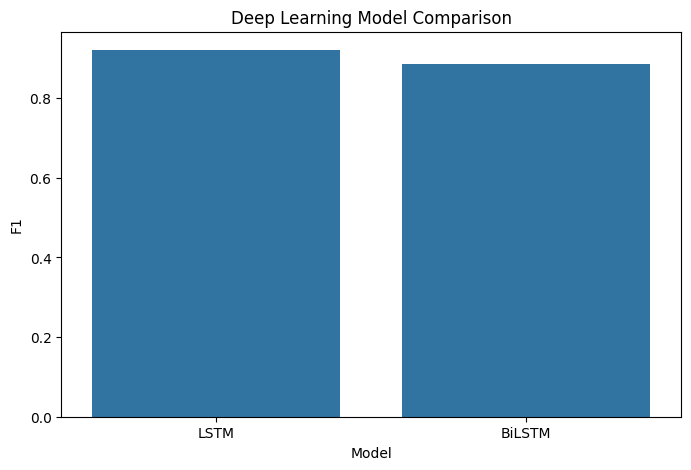

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=dl_results,
    x="Model",
    y="F1"
)

plt.title(
    "Deep Learning Model Comparison"
)

plt.savefig(
    "../results/figures/deep_learning_comparison.png",
    bbox_inches="tight"
)

plt.show()

# Conclusion

Several important findings emerged throughout the experimentation process:

- Initial LSTM experiments suffered from severe majority-class bias.
- Diagnostic analysis revealed that the model was predicting almost all messages as ham.
- Class weighting and architectural refinement successfully addressed this issue.
- The refined LSTM model achieved strong performance with an F1-Score of 92.06%.
- BiLSTM achieved competitive performance but did not surpass the standard LSTM architecture.
- Increased model complexity did not guarantee improved classification results.

Final ranking of deep learning models:

| Rank | Model | F1-Score |
|------|--------|-----------|
| 1 | LSTM | 0.9206 |
| 2 | BiLSTM | 0.8852 |

Overall, the LSTM architecture emerged as the most effective deep learning approach for this dataset.

The next stage of the project will investigate transformer-based architectures to determine whether modern attention-based models can outperform both traditional machine learning methods and recurrent neural networks for spam detection.